In [681]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, log_loss, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer

In [682]:
df = pd.read_csv('data/train.csv')

In [683]:
df.Ticket.value_counts()

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64

In [684]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [685]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [686]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Извлекаем статус из имени

In [687]:
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Countess': 'Rare', 'Lady': 'Rare', 'Sir': 'Rare', 'Don': 'Rare', 'Jonkheer': 'Rare',
    'Capt': 'Rare', 'Major': 'Rare', 'Col': 'Rare', 'Dr': 'Rare', 'Rev': 'Rare'
}
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(title_map)
df['Title'] = df['Title'].where(df['Title'].isin(['Mr','Mrs','Miss','Master','Rare']), 'Rare')
df.Title.value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

### Добавляем признак наличия членов семьи на борту

In [688]:
df['HasFamily'] = df['SibSp'] + df['Parch']
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,HasFamily
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,0


In [689]:
imp_feats = df.drop(['Survived'], axis=1)
target = df['Survived']

In [690]:
target.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Посмотрим на графики для разных признаков

Text(0.5, 0, 'Survived')

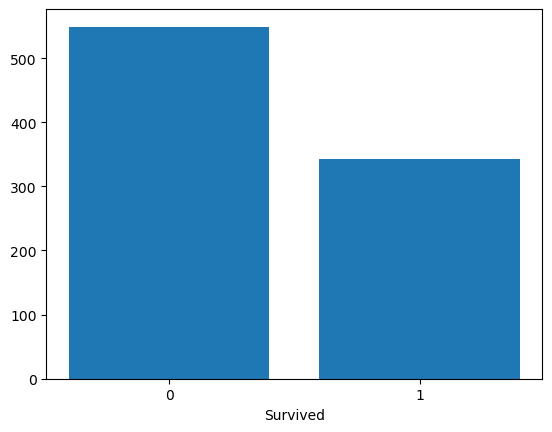

In [691]:
plt.bar(df['Survived'].unique(), df['Survived'].value_counts(), tick_label = ['0', '1'])
plt.xlabel('Survived')

In [692]:
port = df['Embarked'].fillna('Unknown')

Text(0.5, 0, 'Embarked')

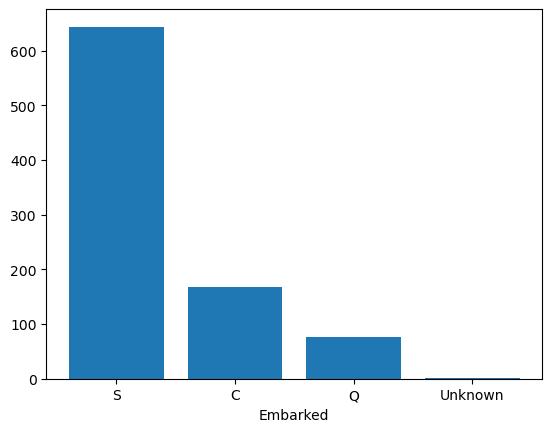

In [693]:
plt.bar(port.unique(), port.value_counts(), tick_label = ['S', 'C', 'Q', 'Unknown'])
plt.xlabel('Embarked')

<Axes: xlabel='Pclass', ylabel='count'>

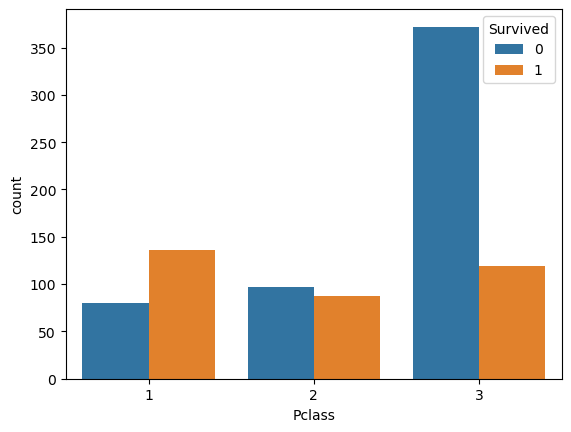

In [694]:
sns.countplot(x = 'Pclass', hue = 'Survived', data = df)

### В 3 классе больше всего погибших, в 1 больше всего выживших

<Axes: xlabel='Sex', ylabel='count'>

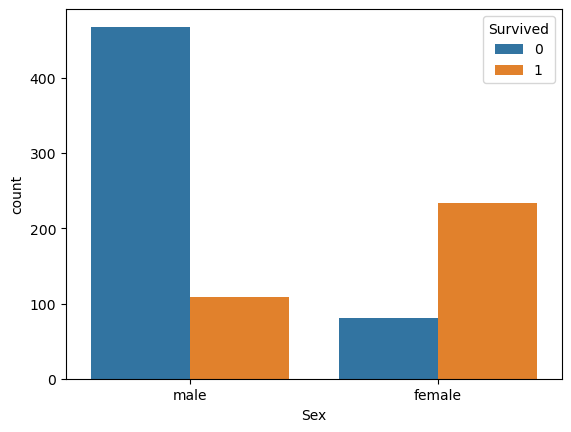

In [695]:
sns.countplot(x = 'Sex', hue = 'Survived', data = df)

### Смотрим числовые признаки

Нормальное распределение только у Age

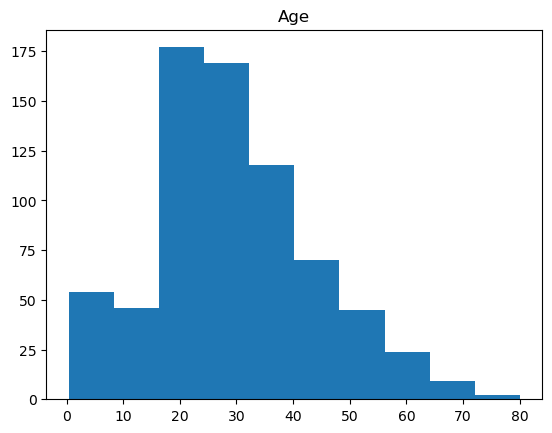

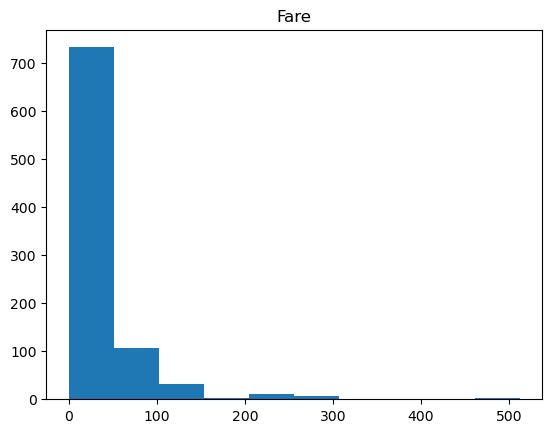

In [696]:
df_num = df[['Age', 'Fare']]

for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

### Смотрим корреляцию

<Axes: >

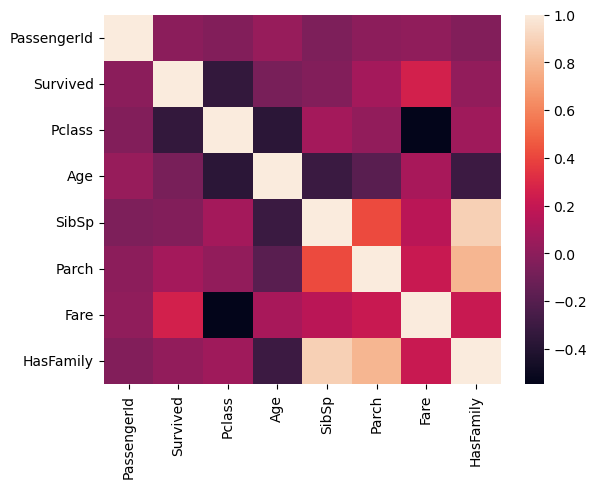

In [697]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

Хорошая корреляция у (SibSp, Parch), (Fare, Survived)

In [698]:
pd.pivot_table(df, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


### Подготовка к обучению

In [699]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,HasFamily
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,0


In [700]:
df_clean = df.drop(['SibSp', 'Parch', 'Ticket'], axis=1)
df_clean

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,HasFamily
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C85,C,Mrs,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,NaN,S,Miss,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,C123,S,Mrs,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,NaN,S,Mr,0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,13.0000,NaN,S,Rare,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,30.0000,B42,S,Miss,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,23.4500,NaN,S,Miss,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,30.0000,C148,C,Mr,0


### Выбираем нужные признаки

In [701]:
imp_feats = df_clean.drop(['Survived', 'PassengerId', 'Cabin', 'Name'], axis=1).copy()
target = df['Survived']

imp_feats

,Pclass,Sex,Age,Fare,Embarked,Title,HasFamily
0,3,male,22.0,7.2500,S,Mr,1
1,1,female,38.0,71.2833,C,Mrs,1
2,3,female,26.0,7.9250,S,Miss,0
3,1,female,35.0,53.1000,S,Mrs,1
4,3,male,35.0,8.0500,S,Mr,0
...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,Rare,0
887,1,female,19.0,30.0000,S,Miss,0
888,3,female,NaN,23.4500,S,Miss,3
889,1,male,26.0,30.0000,C,Mr,0


In [702]:
X_train, X_test, y_train, y_test = train_test_split(imp_feats, target, stratify=target, test_size= 0.2, random_state=21)

In [703]:
num_feats = ['Age', 'HasFamily', 'Social_Rank', 'Fare']
cat_feats = ['Pclass', 'Sex', 'Embarked']

### Собираем Pipeline

In [ ]:
num_prep = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
cat_prep = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = make_column_transformer((num_prep, num_feats), (cat_prep, cat_feats))

In [705]:
models = {
    'Dummy': DummyClassifier(random_state=21, strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(random_state=21),
    'Decision Tree': DecisionTreeClassifier(random_state=21),
    'SVM': SVC(probability=True, random_state=21),
    'KNN': KNeighborsClassifier(n_neighbors=8),
    'Random Forest': RandomForestClassifier(random_state=21)
}

In [706]:
test_score = pd.DataFrame(columns=['model', 'accuracy', 'neg_log_loss', 'precision', 'recall', 'roc_auc'])
train_score = pd.DataFrame(columns=test_score.columns)

### Обучаем baseline

In [707]:
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

In [708]:
for name, model in models.items():
    base_pipe = make_pipeline(
        preprocessor, 
        model
    )

    #кросс-валидация ценит абсолютное значение, а так как хорошая logloss стремится к нулю, берем её со знаком "1", чтобы модель правильно работала
    cv_res = cross_validate(base_pipe, X_train, y_train, scoring=list(test_score.columns[1:]), cv=strat_kfold, n_jobs=-1, return_train_score=True)
    
    mean_accuracy_test  = cv_res['test_accuracy'].mean()
    mean_logloss_test   = -cv_res['test_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_test = cv_res['test_precision'].mean()
    mean_recall_test    = cv_res['test_recall'].mean()
    mean_roc_auc_test   = cv_res['test_roc_auc'].mean()

    mean_accuracy_train  = cv_res['train_accuracy'].mean()
    mean_logloss_train   = -cv_res['train_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_train = cv_res['train_precision'].mean()
    mean_recall_train    = cv_res['train_recall'].mean()
    mean_roc_auc_train   = cv_res['train_roc_auc'].mean()

    test_score.loc[len(test_score)] = [
        name, 
        mean_accuracy_test, 
        mean_logloss_test, 
        mean_precision_test, 
        mean_recall_test, 
        mean_roc_auc_test
    ]

    train_score.loc[len(train_score)] = [
            name, 
            mean_accuracy_train, 
            mean_logloss_train, 
            mean_precision_train, 
            mean_recall_train, 
            mean_roc_auc_train
        ]

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\anaconda3\Lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'Social_Rank'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\_indexing.py", line 443, in _get_column_indices
    col_idx = all_columns.get_loc(col)
  File "c:\Users\user\anaconda3\Lib\site-packages\pandas\core\indexes\base.py", line 3819, in get_loc
    raise KeyError(key) from err
KeyError: 'Social_Rank'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 655, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 589, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ~~~~~~~~~~~~~~~~~~~~~~~~^
        cloned_transformer,
        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
        params=step_params,
        ^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\user\anaconda3\Lib\site-packages\joblib\memory.py", line 326, in __call__
    return self.func(*args, **kwargs)
           ~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 1540, in _fit_transform_one
    res = transformer.fit_transform(X, y, **params.get("fit_transform", {}))
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py", line 988, in fit_transform
    self._validate_column_callables(X)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py", line 541, in _validate_column_callables
    transformer_to_input_indices[name] = _get_column_indices(X, columns)
                                         ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\_indexing.py", line 451, in _get_column_indices
    raise ValueError("A given column is not a column of the dataframe") from e
ValueError: A given column is not a column of the dataframe


In [ ]:
train_score.sort_values(by='roc_auc', ascending=False)

,model,accuracy,neg_log_loss,precision,recall,roc_auc
2,Decision Tree,0.989115,0.021268,0.996249,0.975271,0.999617
5,Random Forest,0.989115,0.114135,0.993509,0.978024,0.997898
4,KNN,0.832167,0.344827,0.869069,0.662096,0.913872
3,SVM,0.834979,0.410252,0.842543,0.703301,0.877292
1,Logistic Regression,0.798457,0.444111,0.758995,0.695053,0.850978
0,Dummy,0.616573,13.820101,0.000000,0.000000,0.500000


### Видим, что `Random Forest` и `Decision Tree` экстремально сильно переобучены, неутешительные результаты показывает также `KNN`

In [ ]:
df_val = test_score.set_index('model')
df_train = train_score.set_index('model')

df_val['neg_log_loss'] = df_val['neg_log_loss'].abs()
df_train['neg_log_loss'] = df_train['neg_log_loss'].abs()

df_val = df_val.rename(columns={'neg_log_loss': 'log_loss'})
df_train = df_train.rename(columns={'neg_log_loss': 'log_loss'})

pct_diff = ((df_val - df_train) / df_train) * 100
pct_diff_sorted = pct_diff.sort_values(by='roc_auc', ascending=False)

pct_diff_sorted = pct_diff_sorted.round(2).astype(str) + '%'
pct_diff_sorted.loc['Dummy', ['precision', 'recall']] = '0.0%'

pct_diff_sorted

,accuracy,log_loss,precision,recall,roc_auc
model,,,,,
Dummy,0.0%,-0.0%,0.0%,0.0%,0.0%
Logistic Regression,-0.79%,2.56%,-0.53%,-1.44%,-0.73%
SVM,-3.61%,11.37%,-5.41%,-6.23%,-3.61%
KNN,-4.64%,380.11%,-5.57%,-10.39%,-7.84%
Random Forest,-19.48%,761.81%,-24.83%,-27.3%,-14.89%
Decision Tree,-21.47%,36861.01%,-27.22%,-28.96%,-24.03%


### Также посмотрим на то, как сильно будут отличаться метрики для моделей, если обучить их на **неотмасштабированных** данных

In [ ]:
test_score_not_scaled = pd.DataFrame(columns=test_score.columns)
train_score_not_scaled = pd.DataFrame(columns=test_score.columns)

In [ ]:
for name, model in models.items():
    base_pipe = make_pipeline(
        make_column_transformer((make_pipeline(SimpleImputer(strategy='median')), num_feats), (cat_prep, cat_feats)), 
        model
    )
    
    cv_res = cross_validate(base_pipe, X_train, y_train, scoring=list(test_score_not_scaled.columns[1:]), cv=strat_kfold, n_jobs=-1, return_train_score=True)
    
    mean_accuracy_test  = cv_res['test_accuracy'].mean()
    mean_logloss_test   = -cv_res['test_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_test = cv_res['test_precision'].mean()
    mean_recall_test    = cv_res['test_recall'].mean()
    mean_roc_auc_test   = cv_res['test_roc_auc'].mean()

    mean_accuracy_train  = cv_res['train_accuracy'].mean()
    mean_logloss_train   = -cv_res['train_neg_log_loss'].mean()  # умножаем на -1, чтобы убрать минус
    mean_precision_train = cv_res['train_precision'].mean()
    mean_recall_train    = cv_res['train_recall'].mean()
    mean_roc_auc_train   = cv_res['train_roc_auc'].mean()

    test_score_not_scaled.loc[len(test_score_not_scaled)] = [
        f'{name}_not_scaled', 
        mean_accuracy_test, 
        mean_logloss_test, 
        mean_precision_test, 
        mean_recall_test, 
        mean_roc_auc_test
    ]

    train_score_not_scaled.loc[len(train_score_not_scaled)] = [
            f'{name}_not_scaled', 
            mean_accuracy_train, 
            mean_logloss_train, 
            mean_precision_train, 
            mean_recall_train, 
            mean_roc_auc_train
        ]

### На тестовой выборке все "отмасштабированные" модели показали лучшие результаты

In [ ]:
test_score_not_scaled.sort_values(by='roc_auc', ascending=False, ignore_index=True)

,model,accuracy,neg_log_loss,precision,recall,roc_auc
0,Random Forest_not_scaled,0.797873,0.984183,0.747745,0.714680,0.848976
1,Logistic Regression_not_scaled,0.793549,0.456226,0.756000,0.688754,0.844656
2,KNN_not_scaled,0.728908,1.354738,0.716988,0.476700,0.766168
3,Decision Tree_not_scaled,0.779582,7.759257,0.727052,0.700202,0.763343
4,SVM_not_scaled,0.682567,0.613766,0.711999,0.296768,0.743915
5,Dummy_not_scaled,0.616576,13.819988,0.000000,0.000000,0.500000


### На обучающей выборке все "отмасштабированные" модели также показали лучшие результаты

In [ ]:
train_score_not_scaled.sort_values(by='roc_auc', ascending=False, ignore_index=True)

,model,accuracy,neg_log_loss,precision,recall,roc_auc
0,Decision Tree_not_scaled,0.989115,0.021268,0.996249,0.975271,0.999617
1,Random Forest_not_scaled,0.989115,0.113962,0.993509,0.978024,0.997880
2,Logistic Regression_not_scaled,0.797404,0.444319,0.756739,0.695057,0.850868
3,KNN_not_scaled,0.771773,0.458397,0.778138,0.566872,0.844018
4,SVM_not_scaled,0.687148,0.605673,0.717500,0.304055,0.756550
5,Dummy_not_scaled,0.616573,13.820101,0.000000,0.000000,0.500000


### И тут точно так же присутствует проблема переобученности `Random Forest` и `Decision Tree`

In [ ]:
df_val_nsc = test_score_not_scaled.set_index('model')
df_train_nsc = train_score_not_scaled.set_index('model')

df_val_nsc['neg_log_loss'] = df_val_nsc['neg_log_loss'].abs()
df_train_nsc['neg_log_loss'] = df_train_nsc['neg_log_loss'].abs()

df_val_nsc = df_val_nsc.rename(columns={'neg_log_loss': 'log_loss'})
df_train_nsc = df_train_nsc.rename(columns={'neg_log_loss': 'log_loss'})

pct_diff_nsc = ((df_val_nsc - df_train_nsc) / df_train_nsc) * 100

pct_diff_nsc_sorted = pct_diff_nsc.sort_values(by='roc_auc', ascending=False)

pct_diff_styled_nsc = pct_diff_nsc_sorted.round(2).astype(str) + '%'
pct_diff_styled_nsc.loc['Dummy_not_scaled', ['precision', 'recall']] = '0.0%'

pct_diff_styled_nsc

,accuracy,log_loss,precision,recall,roc_auc
model,,,,,
Dummy_not_scaled,0.0%,-0.0%,0.0%,0.0%,0.0%
Logistic Regression_not_scaled,-0.48%,2.68%,-0.1%,-0.91%,-0.73%
SVM_not_scaled,-0.67%,1.34%,-0.77%,-2.4%,-1.67%
KNN_not_scaled,-5.55%,195.54%,-7.86%,-15.91%,-9.22%
Random Forest_not_scaled,-19.33%,763.61%,-24.74%,-26.93%,-14.92%
Decision Tree_not_scaled,-21.18%,36383.62%,-27.02%,-28.2%,-23.64%


In [ ]:
scal_diff_test = ((test_score.drop('model', axis=1) - test_score_not_scaled.drop('model', axis=1)) / test_score.drop('model', axis=1) * 100).sort_values('roc_auc', ascending=False)
scal_diff_test = pd.concat([test_score.model, scal_diff_test], axis=1).set_index('model').round(2).astype(str) + '%'
scal_diff_test.loc['Dummy', ['precision', 'recall']] = '0.0%'
scal_diff_test

,accuracy,neg_log_loss,precision,recall,roc_auc
model,,,,,
Dummy,0.0%,0.0%,0.0%,0.0%,0.0%
Logistic Regression,-0.18%,-0.16%,-0.14%,-0.54%,0.01%
Decision Tree,-0.36%,1.29%,-0.28%,-1.07%,-0.52%
SVM,15.19%,-34.33%,10.66%,55.0%,12.02%
KNN,8.15%,18.17%,12.63%,19.66%,9.03%
Random Forest,-0.18%,-0.06%,-0.12%,-0.52%,0.04%


In [ ]:
scal_diff_train = ((train_score.drop('model', axis=1) - train_score_not_scaled.drop('model', axis=1)) / train_score.drop('model', axis=1) * 100).sort_values('roc_auc', ascending=False)
scal_diff_train = pd.concat([train_score.model, scal_diff_train], axis=1).set_index('model').round(2).astype(str) + '%'
scal_diff_train.loc['Dummy', ['precision', 'recall']] = '0.0%'
scal_diff_train

,accuracy,neg_log_loss,precision,recall,roc_auc
model,,,,,
Dummy,0.0%,0.0%,0.0%,0.0%,0.0%
Logistic Regression,0.13%,-0.05%,0.3%,-0.0%,0.01%
Decision Tree,0.0%,0.0%,0.0%,0.0%,0.0%
SVM,17.7%,-47.63%,14.84%,56.77%,13.76%
KNN,7.26%,-32.94%,10.46%,14.38%,7.64%
Random Forest,0.0%,0.15%,0.0%,0.0%,0.0%


## Промежуточный итог по метрикам моделей:

- Лучшая модель по `ROC-AUC` - `Random Forest`, но модель оказалась сильно переобученной, как и `KNN`
- Самая стабильная модель - `Logistic Regression` и `SVC`
- Лучшая модель по `accuracy` и `log_loss` - `SVC`
- Модель, меньше всего подверженная переобучению - `Logistic Regression`
- Масштабирование имеет критическое значение для моделей `SVC` и `KNN`

---

### **Следующий этап**: обучение моделей с подбором лучших гиперпараметров через GridSearch и RandomSearch

In [ ]:
scikit_scoring = {
    'accuracy': 'accuracy',
    'logloss': 'neg_log_loss',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

In [ ]:
grid_params = [
    {
        'model': [LogisticRegression(random_state=21)],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model': [SVC(probability=True, random_state=21)],
        'model__kernel': ['linear', 'rbf'],
        'model__C': [0.01, 0.1, 1, 10]
    },
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': [5, 8, 10],
        'model__metric': ['euclidean']
    }
]

rand_params = [
    {
        'model': [RandomForestClassifier(random_state=21)],
        'model__n_estimators': np.linspace(20, 200, 10, dtype=int),
        'model__max_depth': np.linspace(5, 100, 5, dtype=int),
        'model__min_samples_split': [2, 5]
    },
    {
        'model': [DecisionTreeClassifier(random_state=21)],
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': np.linspace(5, 100, 5, dtype=int),
        'model__min_samples_split': [2, 5]
    }
]

In [ ]:
base_pipe = Pipeline([
    ('preprocess', preprocessor), 
    ('model', [LogisticRegression(solver='liblinear')])
        
])

In [ ]:
grid_search = GridSearchCV(base_pipe, grid_params, cv=strat_kfold, verbose=3, scoring=scikit_scoring, refit='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 19 candidates, totalling 95 fits


,estimator,Pipeline(step...iblinear')])])
,param_grid,"[{'model': [LogisticRegre...ndom_state=21)], 'model__C': [0.01, 0.1, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}, {'model': [SVC(probabili...ndom_state=21)], 'model__C': [0.01, 0.1, ...], 'model__kernel': ['linear', 'rbf']}, ...]"
,scoring,"{'accuracy': 'accuracy', 'logloss': 'neg_log_loss', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"


In [ ]:
random_search = RandomizedSearchCV(
    base_pipe, rand_params, 
    n_iter=20, cv=strat_kfold, scoring=scikit_scoring, 
    refit='roc_auc', n_jobs=-1, random_state=21
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step...iblinear')])])
,param_distributions,"[{'model': [RandomForestC...ndom_state=21)], 'model__max_depth': array([ 5, ...52, 76, 100]), 'model__min_samples_split': [2, 5], 'model__n_estimators': array([ 20, ...60, 180, 200])}, {'model': [DecisionTreeC...ndom_state=21)], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': array([ 5, ...52, 76, 100]), 'model__min_samples_split': [2, 5]}]"
,n_iter,20
,scoring,"{'accuracy': 'accuracy', 'logloss': 'neg_log_loss', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,21
,error_score,nan


In [ ]:
grid_res = pd.DataFrame(grid_search.cv_results_)
grid_res['model'] = grid_res['param_model'].apply(lambda x: x.__class__.__name__)

best_grid = grid_res.sort_values('rank_test_roc_auc').set_index('rank_test_roc_auc')
best_grid

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model,param_model__C,param_model__penalty,param_model__solver,param_model__kernel,param_model__metric,...,std_test_recall,rank_test_recall,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,model
rank_test_roc_auc,,,,,,,,,,,,,,,,,,,,,
1,0.092677,0.026964,0.064527,0.021546,"SVC(probability=True, random_state=21)",0.01,NaN,NaN,linear,NaN,...,0.040714,8,0.806302,0.855579,0.834596,0.901936,0.849530,0.849588,0.031224,SVC
2,0.014861,0.002934,0.037881,0.009132,KNeighborsClassifier(),NaN,NaN,NaN,NaN,euclidean,...,0.048096,15,0.815806,0.862397,0.851010,0.884259,0.833438,0.849382,0.023537,KNeighborsClassifier
3,0.013578,0.000810,0.033094,0.005129,LogisticRegression(random_state=21),0.10,l1,liblinear,NaN,NaN,...,0.049462,12,0.798037,0.853616,0.837121,0.889731,0.856426,0.846986,0.029845,LogisticRegression
4,0.011763,0.001941,0.029340,0.002102,LogisticRegression(random_state=21),0.10,l2,liblinear,NaN,NaN,...,0.054688,7,0.796798,0.855785,0.832912,0.894150,0.851829,0.846295,0.031749,LogisticRegression
5,0.141650,0.035520,0.076187,0.028302,"SVC(probability=True, random_state=21)",1.00,NaN,NaN,rbf,NaN,...,0.061290,13,0.779236,0.863223,0.838173,0.881524,0.865831,0.845597,0.035972,SVC
6,0.014833,0.000312,0.031424,0.002453,LogisticRegression(random_state=21),1.00,l1,liblinear,NaN,NaN,...,0.051164,2,0.792665,0.860124,0.832281,0.890152,0.849948,0.845034,0.032226,LogisticRegression
7,0.012052,0.001347,0.030297,0.007223,LogisticRegression(random_state=21),1.00,l2,liblinear,NaN,NaN,...,0.054529,5,0.792252,0.859917,0.832702,0.889941,0.849530,0.844868,0.032237,LogisticRegression
8,0.013820,0.000536,0.037716,0.004849,LogisticRegression(random_state=21),10.00,l2,liblinear,NaN,NaN,...,0.055397,3,0.791219,0.859504,0.831650,0.890362,0.849530,0.844453,0.032734,LogisticRegression
9,0.014200,0.003272,0.031133,0.003438,LogisticRegression(random_state=21),10.00,l1,liblinear,NaN,NaN,...,0.055397,3,0.791219,0.859298,0.831229,0.890362,0.849112,0.844244,0.032736,LogisticRegression


In [ ]:
roc_auc_splits = ['split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc']
best_grid['mean_test_roc_auc'] = best_grid[roc_auc_splits].mean(axis=1)
best_grid['std_test_roc_auc'] = best_grid[roc_auc_splits].std(axis=1)
best_grid[['model', 'mean_test_roc_auc', 'std_test_roc_auc']].sort_values('mean_test_roc_auc', ascending=False)

,model,mean_test_roc_auc,std_test_roc_auc
rank_test_roc_auc,,,
1,SVC,0.849588,0.034909
2,KNeighborsClassifier,0.849382,0.026316
3,LogisticRegression,0.846986,0.033367
4,LogisticRegression,0.846295,0.035496
5,SVC,0.845597,0.040217
6,LogisticRegression,0.845034,0.036030
7,LogisticRegression,0.844868,0.036042
8,LogisticRegression,0.844453,0.036598
9,LogisticRegression,0.844244,0.036600


### **Лучшая модель по `GridSearch` - `SVC`**

In [ ]:
rand_res = pd.DataFrame(random_search.cv_results_)
rand_res['model'] = rand_res['param_model'].apply(lambda x: x.__class__.__name__)
best_rand = rand_res.sort_values('rank_test_roc_auc').set_index('rank_test_roc_auc')
best_rand.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__max_depth,param_model,param_model__criterion,params,...,std_test_recall,rank_test_recall,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,model
rank_test_roc_auc,,,,,,,,,,,,,,,,,,,,,
1,0.438023,0.111073,0.073741,0.023476,160.0,2,5,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 160, 'model__min_sampl...",...,0.072587,18,0.810950,0.887603,0.877315,0.918245,0.838036,0.866430,0.037778,RandomForestClassifier
2,0.176342,0.008503,0.030503,0.004816,80.0,5,5,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 80, 'model__min_sample...",...,0.064719,19,0.805475,0.885950,0.881313,0.917719,0.838454,0.865782,0.039317,RandomForestClassifier
3,0.521322,0.116628,0.067360,0.020063,200.0,5,5,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 200, 'model__min_sampl...",...,0.068197,17,0.810124,0.888430,0.878998,0.916456,0.834274,0.865656,0.038330,RandomForestClassifier
4,0.565807,0.156002,0.075846,0.035507,200.0,5,100,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 200, 'model__min_sampl...",...,0.069493,3,0.817149,0.855785,0.864478,0.895833,0.830408,0.852731,0.027457,RandomForestClassifier
5,0.371278,0.092632,0.059465,0.014808,140.0,5,28,RandomForestClassifier(random_state=21),NaN,"{'model__n_estimators': 140, 'model__min_sampl...",...,0.078199,7,0.813636,0.851446,0.864478,0.895097,0.834065,0.851744,0.027592,RandomForestClassifier


In [ ]:
roc_auc_splits = ['split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc']
best_rand['mean_test_roc_auc'] = best_rand[roc_auc_splits].mean(axis=1)
best_rand['std_test_roc_auc'] = best_rand[roc_auc_splits].std(axis=1)

best_rand[['model', 'mean_test_roc_auc', 'std_test_roc_auc']].sort_values('mean_test_roc_auc', ascending=False)

,model,mean_test_roc_auc,std_test_roc_auc
rank_test_roc_auc,,,
1,RandomForestClassifier,0.866430,0.042237
2,RandomForestClassifier,0.865782,0.043958
3,RandomForestClassifier,0.865656,0.042854
4,RandomForestClassifier,0.852731,0.030698
5,RandomForestClassifier,0.851744,0.030848
6,RandomForestClassifier,0.851226,0.032408
7,RandomForestClassifier,0.850773,0.030051
8,RandomForestClassifier,0.850140,0.029900
9,RandomForestClassifier,0.849383,0.028286


### **Лучшая модель по `RandomSearch` - `RandomForestClassifier`**

## Лучший показатель среди моделей с перебранными параметрами - `RandomForestClassifier` с метрикой `roc-auc` = **0.866430**

---

### Добавим оценку с помощью ансамбля Voting Classifier

In [ ]:
best_of_the_best = pd.concat([best_grid, best_rand])[['model', 'params', 'mean_test_roc_auc']]
best_by_model = best_of_the_best.groupby('model', as_index=False).apply(
    lambda group: group.sort_values(by='mean_test_roc_auc', ascending=False).iloc[0]
)

best_by_model = best_by_model.sort_values(by='mean_test_roc_auc', ascending=False).reset_index(drop=True)
best_by_model

C:\Users\user\AppData\Local\Temp\ipykernel_21148\3852494621.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_by_model = best_of_the_best.groupby('model', as_index=False).apply(


,model,params,mean_test_roc_auc
0,RandomForestClassifier,"{'model__n_estimators': 160, 'model__min_sampl...",0.866430
1,SVC,"{'model': SVC(probability=True, random_state=2...",0.849588
2,KNeighborsClassifier,"{'model': KNeighborsClassifier(), 'model__metr...",0.849382
3,LogisticRegression,"{'model': LogisticRegression(random_state=21),...",0.846986
4,DecisionTreeClassifier,"{'model__min_samples_split': 5, 'model__max_de...",0.824320


In [ ]:
params_for_fitting = []

for params in best_by_model.loc[:, 'params']:
    model_params = {
    key.replace('model__', ''): value
    for key, value in params.items()
    if key != 'model'
    }

    params_for_fitting.append(model_params)

best_by_model.params = params_for_fitting
best_by_model

,model,params,mean_test_roc_auc
0,RandomForestClassifier,"{'n_estimators': 160, 'min_samples_split': 2, ...",0.866430
1,SVC,"{'C': 0.01, 'kernel': 'linear'}",0.849588
2,KNeighborsClassifier,"{'metric': 'euclidean', 'n_neighbors': 10}",0.849382
3,LogisticRegression,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline...",0.846986
4,DecisionTreeClassifier,"{'min_samples_split': 5, 'max_depth': 5, 'crit...",0.824320


### Список моделей с лучшими гиперпараметрами

In [ ]:
models_best = [
    ('lr', LogisticRegression(**best_by_model.loc[3][1], random_state=21)),
    ('svc', SVC(**best_by_model.loc[1][1], random_state=21, probability=True)),
    ('knn', KNeighborsClassifier(**best_by_model.loc[2][1])),
    ('dt', DecisionTreeClassifier(**best_by_model.loc[4][1], random_state=21)),
    ('rf', RandomForestClassifier(**best_by_model.loc[0][1], random_state=21))
]

C:\Users\user\AppData\Local\Temp\ipykernel_21148\1468301045.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ('lr', LogisticRegression(**best_by_model.loc[3][1], random_state=21)),
C:\Users\user\AppData\Local\Temp\ipykernel_21148\1468301045.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ('svc', SVC(**best_by_model.loc[1][1], random_state=21, probability=True)),
C:\Users\user\AppData\Local\Temp\ipykernel_21148\1468301045.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To ac

### Сначала посчитаем метрики для `soft voting`, так как он умеет работать с вероятностями

In [ ]:
from itertools import combinations

soft_vot_res = []
hard_vot_res = []
combs = []

for n in range(2, len(models_best)+1):
    for comb in combinations(models_best, n):
        voting_soft_cl = VotingClassifier(
            estimators=list(comb),
            voting = 'soft'
        )

        voting_hard_cl = VotingClassifier(
            estimators=list(comb),
            voting = 'hard'
        )


        best_soft_pipe = Pipeline([
            ('preprocess', preprocessor),
            ('model', voting_soft_cl)
        ])

        best_hard_pipe = Pipeline([
            ('preprocess', preprocessor),
            ('model', voting_hard_cl)
        ])        

        comb_soft_vot = cross_validate(best_soft_pipe, X_train, y_train, cv=strat_kfold, scoring=scikit_scoring, n_jobs=-1)
        comb_hard_vot = cross_validate(best_hard_pipe, X_train, y_train, cv=strat_kfold, scoring=['accuracy', 'precision', 'recall'], n_jobs=-1)
        soft_vot_res.append(comb_soft_vot)
        hard_vot_res.append(comb_hard_vot)
        
        names = [i[0] for i in comb]
        combs.append('+'.join(names))

In [ ]:
df_soft_vot_res = pd.concat([pd.Series(combs,  name='combination'), pd.DataFrame(soft_vot_res)],  axis = 1)

for i in df_soft_vot_res.columns[1:]:
    df_soft_vot_res[f'{i}'] = df_soft_vot_res[f'{i}'].apply(np.nanmean)
    
df_soft_vot_res = df_soft_vot_res.sort_values('test_roc_auc', ascending=False)
df_soft_vot_res.head()

,combination,fit_time,score_time,test_accuracy,test_logloss,test_precision,test_recall,test_roc_auc
15,lr+dt+rf,0.207890,0.026878,0.811868,-0.426885,0.838956,0.633939,0.864994
18,svc+dt+rf,0.295094,0.038592,0.813228,-0.425468,0.801983,0.681347,0.862598
23,lr+knn+dt+rf,0.224292,0.027289,0.810430,-0.427405,0.835050,0.633872,0.862026
13,lr+knn+dt,0.015780,0.015263,0.813228,-0.431910,0.833059,0.644781,0.862005
6,svc+rf,0.284153,0.029583,0.796405,-0.438436,0.772389,0.666936,0.861354


In [ ]:
df_hard_vot_res = pd.concat([pd.Series(combs,  name='combination'), pd.DataFrame(hard_vot_res)],  axis = 1)

for i in df_hard_vot_res.columns[1:]:
    df_hard_vot_res[f'{i}'] = df_hard_vot_res[f'{i}'].apply(np.nanmean)

df_hard_vot_res = df_hard_vot_res.sort_values('test_accuracy', ascending=False)
df_hard_vot_res

df_hard_vot_res.head()

,combination,fit_time,score_time,test_accuracy,test_precision,test_recall
9,dt+rf,0.191658,0.016822,0.817483,0.868882,0.619192
7,knn+dt,0.013616,0.011658,0.816054,0.840719,0.644781
1,lr+knn,0.017013,0.016147,0.816054,0.809185,0.681414
2,lr+dt,0.014086,0.009248,0.814636,0.852371,0.630168
18,svc+dt+rf,0.258929,0.026130,0.813228,0.801983,0.681347


### Эксперимент показал, что лучший ансамбль состоит из `DecisionTree` и `RandomForest`

### Эксперимент показал, что метрика ансамбля ухудшилась в сравнении с точностью предсказаний одиночного **`DecisionTree`**
---
### Делаем финальные предсказания на лучших моделях и считаем метрики

In [ ]:
pure_rf = RandomForestClassifier(**best_by_model.loc[0][1], random_state=21)
pure_dt = DecisionTreeClassifier(**best_by_model.loc[4][1], random_state=21)

voting_clf = VotingClassifier(
    estimators=[('rf', pure_rf), ('dt', pure_dt)],
    voting='soft'
)

best_voting_pipe = make_pipeline(preprocessor, voting_clf)

best_models = {
    'SVC': grid_search.best_estimator_,
    'Random Forest': random_search.best_estimator_,
    'Voting Ensemble': best_voting_pipe
}

final_score = pd.DataFrame(
    columns=['model', 'accuracy', 'precision', 'recall', 'roc_auc', 'log_loss']
)

for name, pipe in best_models.items():
    
    pipe.fit(X_train, y_train)
    
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    
    final_score.loc[len(final_score)] = [
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        roc_auc_score(y_test, probs),
        log_loss(y_test, probs)
    ]

final_score.sort_values(by='roc_auc', ascending=False).reset_index(drop=True)

C:\Users\user\AppData\Local\Temp\ipykernel_21148\707666151.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pure_rf = RandomForestClassifier(**best_by_model.loc[0][1], random_state=21)
C:\Users\user\AppData\Local\Temp\ipykernel_21148\707666151.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pure_dt = DecisionTreeClassifier(**best_by_model.loc[4][1], random_state=21)


,model,accuracy,precision,recall,roc_auc,log_loss
0,SVC,0.787709,0.718310,0.739130,0.874704,0.474417
1,Random Forest,0.849162,0.838710,0.753623,0.862319,0.430129
2,Voting Ensemble,0.826816,0.779412,0.768116,0.858762,0.439606


In [ ]:
final_score.sort_values(by='accuracy', ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,roc_auc,log_loss
0,Random Forest,0.849162,0.838710,0.753623,0.862319,0.430129
1,Voting Ensemble,0.826816,0.779412,0.768116,0.858762,0.439606
2,SVC,0.787709,0.718310,0.739130,0.874704,0.474417


---
## Анализ ошибок модели SVC

In [ ]:
final_model = best_models['SVC']

In [ ]:
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

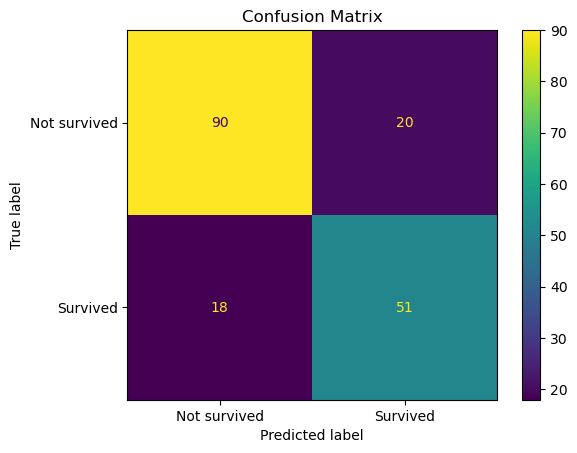

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not survived', 'Survived']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

### Таблица конкретных ошибочных пассажиров

In [ ]:
errors = df.loc[X_test.index].copy()

errors['y_true'] = y_test
errors['y_pred'] = y_pred
errors['probability'] = y_proba

errors = errors[errors['y_true'] != errors['y_pred']]
errors.sort_values('probability', ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Social_Rank,HasFamily,y_true,y_pred,probability
297,298,0,1,Miss,female,2.0,1,2,113781,151.5500,C22 C26,S,1,3,0,1,0.928920
498,499,0,1,Mrs,female,25.0,1,2,113781,151.5500,C22 C26,S,1,3,0,1,0.909915
199,200,0,2,Miss,female,24.0,0,0,248747,13.0000,NaN,S,1,0,0,1,0.812552
111,112,0,3,Miss,female,14.5,1,0,2665,14.4542,NaN,C,1,1,0,1,0.809829
205,206,0,3,Miss,female,2.0,0,1,347054,10.4625,G6,S,1,1,0,1,0.804082
501,502,0,3,Miss,female,21.0,0,0,364846,7.7500,NaN,Q,1,0,0,1,0.794664
807,808,0,3,Miss,female,18.0,0,0,347087,7.7750,NaN,S,1,0,0,1,0.782393
502,503,0,3,Miss,female,NaN,0,0,330909,7.6292,NaN,Q,1,0,0,1,0.780466
140,141,0,3,Mrs,female,NaN,0,2,2678,15.2458,NaN,C,1,2,0,1,0.774282
38,39,0,3,Miss,female,18.0,2,0,345764,18.0000,NaN,S,1,2,0,1,0.771408


### Ошибки по полу

In [ ]:
pd.crosstab(
    errors['Sex'],
    errors['y_true'],
    normalize='index'
)

y_true,0,1
Sex,,
female,1.000000,0.000000
male,0.052632,0.947368


In [ ]:
errors['Sex'].value_counts()

Sex
male      19
female    19
Name: count, dtype: int64

### Ошибки по классу

In [ ]:
pd.crosstab(
    errors['Pclass'],
    errors['y_true']
)

y_true,0,1
Pclass,,
1,3,7
2,1,5
3,16,6


### Ошибки по возрасту

In [ ]:
errors['AgeGroup'] = pd.cut(
    errors['Age'],
    bins=[0, 12, 18, 30, 50, 100],
    labels=['Child', 'Teen', 'Young adult', 'Adult', 'Senior']
)

errors['AgeGroup'].value_counts()

AgeGroup
Young adult    13
Child           8
Adult           8
Teen            3
Senior          0
Name: count, dtype: int64

### Самые уверенные ошибки модели

In [ ]:
errors['confidence'] = np.where(
    errors['y_pred'] == 1,
    errors['probability'],
    1 - errors['probability']
)

errors.sort_values(
    'confidence',
    ascending=False
)[[
    'Name',
    'Sex',
    'Age',
    'Pclass',
    'y_true',
    'y_pred',
    'probability',
    'confidence'
]].head(10)

,Name,Sex,Age,Pclass,y_true,y_pred,probability,confidence
297,Miss,female,2.0,1,0,1,0.928920,0.928920
498,Mrs,female,25.0,1,0,1,0.909915,0.909915
804,Mr,male,27.0,3,1,0,0.147295,0.852705
709,Master,male,NaN,3,1,0,0.154854,0.845146
510,Mr,male,29.0,3,1,0,0.158938,0.841062
288,Mr,male,42.0,2,1,0,0.159098,0.840902
283,Mr,male,19.0,3,1,0,0.159829,0.840171
869,Master,male,4.0,3,1,0,0.167957,0.832043
673,Mr,male,31.0,2,1,0,0.176289,0.823711
207,Mr,male,26.0,3,1,0,0.179737,0.820263


### Строим ROC-кривую

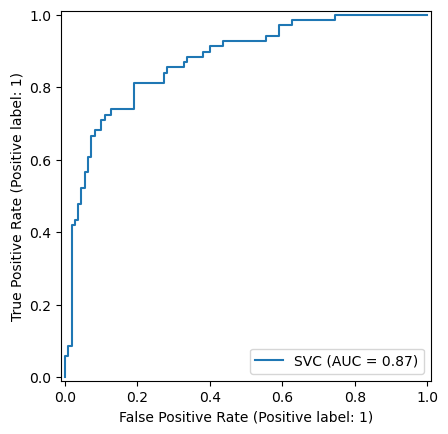

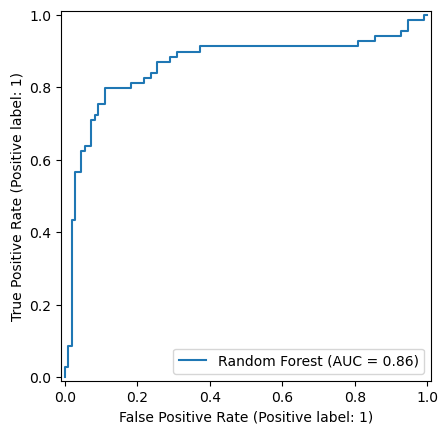

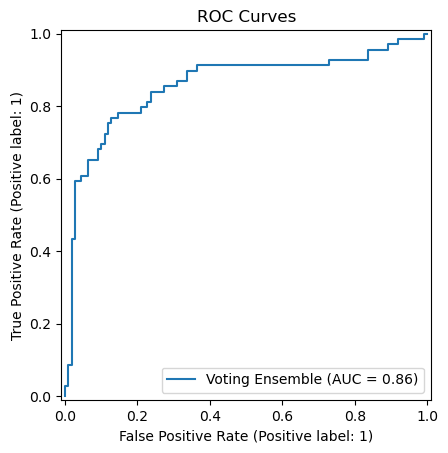

In [ ]:
for name, model in best_models.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=name
    )

plt.title('ROC Curves')
plt.show()

## Feature Importance

In [ ]:
from sklearn.inspection import permutation_importance

svc = best_models['SVC']

svc.fit(X_train, y_train)

perm = permutation_importance(
    svc,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    random_state=21,
    n_jobs=-1
)

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

feature_importance

,feature,importance,std
1,Sex,0.232543,0.037531
0,Pclass,0.034335,0.013316
2,Age,0.022536,0.004049
3,Fare,0.018248,0.016845
6,HasFamily,0.013900,0.006287
4,Embarked,0.007312,0.004180
5,Social_Rank,0.000804,0.000508


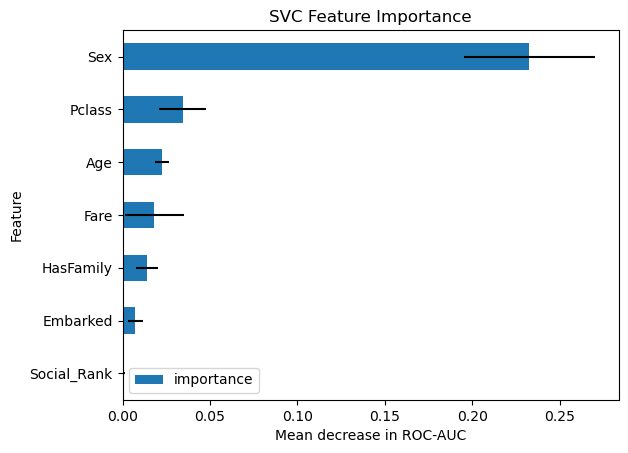

In [ ]:
feature_importance.head(15).plot(
    x='feature',
    y='importance',
    kind='barh',
    xerr='std'
)

plt.gca().invert_yaxis()
plt.title('SVC Feature Importance')
plt.xlabel('Mean decrease in ROC-AUC')
plt.ylabel('Feature')
plt.show()

## ***Итоговый анализ:***

### 1. Лучшая модель по `ROC-AUC` - `SVC`, показатель - `0.874704`
### 2. Лучшая модель по `accuracy` - `Random Forest`, показатель - `0.849162`
### 3. Ансамбль не первысил метрику лучшей одиночной модели
### 4. Модель преимущественно ошибается в предсказаниях для объектов 3 класса возрастной категории 0-12 лет
### 5. Наиболее важный признак - `Sex`, топ 3 - `Pclass` и `Age`


In [ ]:
test = pd.read_csv('data/test.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
test['Name'] = test['Name'].str.extract(
    ' ([A-Za-z]+)\.',
    expand=False
)

test['Social_Rank'] = (
    test['Name']
    .map(rank_map)
    .fillna(1)
    .astype(int)
)

test['HasFamily'] = test['SibSp'] + test['Parch']

test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Social_Rank,HasFamily
0,892,3,Mr,male,34.5,0,0,330911,7.8292,NaN,Q,1,0
1,893,3,Mrs,female,47.0,1,0,363272,7.0000,NaN,S,1,1
2,894,2,Mr,male,62.0,0,0,240276,9.6875,NaN,Q,1,0
3,895,3,Mr,male,27.0,0,0,315154,8.6625,NaN,S,1,0
4,896,3,Mrs,female,22.0,1,1,3101298,12.2875,NaN,S,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Mr,male,NaN,0,0,A.5. 3236,8.0500,NaN,S,1,0
414,1306,1,Dona,female,39.0,0,0,PC 17758,108.9000,C105,C,1,0
415,1307,3,Mr,male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,1,0
416,1308,3,Mr,male,NaN,0,0,359309,8.0500,NaN,S,1,0


In [ ]:
test_clean = test.drop(
    ['SibSp', 'Parch', 'Ticket'],
    axis=1
)

test_clean

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Social_Rank,HasFamily
0,892,3,Mr,male,34.5,7.8292,NaN,Q,1,0
1,893,3,Mrs,female,47.0,7.0000,NaN,S,1,1
2,894,2,Mr,male,62.0,9.6875,NaN,Q,1,0
3,895,3,Mr,male,27.0,8.6625,NaN,S,1,0
4,896,3,Mrs,female,22.0,12.2875,NaN,S,1,2
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,Mr,male,NaN,8.0500,NaN,S,1,0
414,1306,1,Dona,female,39.0,108.9000,C105,C,1,0
415,1307,3,Mr,male,38.5,7.2500,NaN,S,1,0
416,1308,3,Mr,male,NaN,8.0500,NaN,S,1,0


In [ ]:
X_kaggle = test_clean.drop(
    ['PassengerId', 'Cabin', 'Name'],
    axis=1
)

X_kaggle

,Pclass,Sex,Age,Fare,Embarked,Social_Rank,HasFamily
0,3,male,34.5,7.8292,Q,1,0
1,3,female,47.0,7.0000,S,1,1
2,2,male,62.0,9.6875,Q,1,0
3,3,male,27.0,8.6625,S,1,0
4,3,female,22.0,12.2875,S,1,2
...,...,...,...,...,...,...,...
413,3,male,NaN,8.0500,S,1,0
414,1,female,39.0,108.9000,C,1,0
415,3,male,38.5,7.2500,S,1,0
416,3,male,NaN,8.0500,S,1,0


In [ ]:
X_train.columns == X_kaggle.columns

array([ True,  True,  True,  True,  True,  True,  True])

### Создадим несколько файлов с предсказаниями (для 3 моделей)

In [ ]:
best_svc = best_models['SVC']
best_svc.fit(X_train, y_train)
svc_preds = best_svc.predict(X_kaggle)

submission_svc = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': svc_preds
})

submission_svc

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
best_rf = best_models['Random Forest']
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_kaggle)

submission_rf = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': rf_preds
})

submission_rf

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
best_vot = best_models['Voting Ensemble']
best_vot.fit(X_train, y_train)
vot_preds = best_vot.predict(X_kaggle)

submission_vot = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': vot_preds
})

submission_vot

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


### Сохраняем `submissions`

In [ ]:
submission_svc.to_csv(
    'submissions/submission_svc.csv',
    index=False
)

submission_rf.to_csv(
    'submissions/submission_rf.csv',
    index=False
)

submission_vot.to_csv(
    'submissions/submission_vot.csv',
    index=False
)

# Итоговый `score`:

### 1. `Random Forest` = 0.77511
### 2. `SVC` = 0.76794
### 3. `Voting Classifier` = 0.76555